# RNA Aptamer (Pepper) Denovo Design

Evaluate the quality of Pepper RNA aptamer variants generated by the finetuned model.

- **Fitness Prediction Correlation**: Log-likelihood vs experimental fluorescence intensity (Pepper 620/530)
- **DMS vs Generative**: Mutation count distribution comparison
- **Sequence Logo**: Mutation site frequency visualization
- **Performance Logo**: Mutation patterns grouped by activity change

In [1]:
import json
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import font_manager
from matplotlib.textpath import TextPath
from matplotlib.patches import PathPatch
from matplotlib.font_manager import FontProperties
import matplotlib.transforms as transforms
from scipy import stats
import warnings

try:
    import design_paths as DP
except ModuleNotFoundError:
    from notebooks.design import design_paths as DP

warnings.filterwarnings('ignore')
APTAMER_DATA_DIR = DP.data_dir() / "aptamer"

# Font setup
FONT_PATH = str(DP.font_path())
try:
    font_manager.fontManager.addfont(FONT_PATH)
    plt.rcParams["font.sans-serif"] = ["Arial"]
except:
    plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams["font.weight"] = "normal"

# Figure saving
PIC_DIR = str(DP.figures_dir())
os.makedirs(PIC_DIR, exist_ok=True)

def save_fig(name):
    """Save current figure as 300dpi PNG and SVG with transparent background."""
    plt.savefig(os.path.join(PIC_DIR, f"{name}.png"), format='png', dpi=300,
                bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(PIC_DIR, f"{name}.svg"), format='svg', dpi=300,
                bbox_inches='tight', transparent=True)

## 1. PEPPER Prediction Correlation

Scatter plots of model log-likelihood vs experimental fluorescence intensity for Pepper 620nm and 530nm systems. Pearson correlation with 95% confidence interval.

In [2]:
# Load merged prediction data (activity + log-likelihood in one file)
with open(APTAMER_DATA_DIR / "pepper_prediction_data.json") as f:
    pepper_data = json.load(f)

systems = {}
for sys_name in ["620", "530"]:
    entries = pepper_data[f"pepper_{sys_name}"]
    activity_list = [e["fluorescence_intensity"] for e in entries if "fluorescence_intensity" in e]
    ll_list = [e["log_likelihood"] for e in entries if "fluorescence_intensity" in e]
    systems[sys_name] = {"activity": activity_list, "ll": ll_list}

for sys_name in ["620", "530"]:
    d = systems[sys_name]
    rho, pval = stats.pearsonr(d["activity"], d["ll"])
    print(f"Pepper {sys_name}: n={len(d['activity'])}, Pearson r={rho:.4f}, p={pval:.4e}")

Pepper 620: n=70, Pearson r=0.8229, p=2.3608e-18
Pepper 530: n=70, Pearson r=0.7752, p=3.3445e-15


In [3]:
def plot_pepper_correlation(ax, activity, ll, title_text):
    """Scatter plot with regression line and 95% CI."""
    activity = np.array(activity)
    ll = np.array(ll)
    n = len(activity)

    rho, pval = stats.pearsonr(activity, ll)

    # Color map: Blue -> Grey -> Orange
    norm = mcolors.Normalize(vmin=activity.min(), vmax=activity.max())
    colors = [
        (61/255, 117/255, 176/255),
        (0.9, 0.9, 0.9),
        (237/255, 135/255, 51/255)
    ]
    cmap = mcolors.LinearSegmentedColormap.from_list("blue_grey_orange", colors)

    sc = ax.scatter(activity, ll, c=activity, cmap=cmap, norm=norm,
                    s=50, alpha=0.9, edgecolors="none", zorder=3)

    # Linear regression + 95% CI
    slope, intercept, r_value, p_value, std_err_slope = stats.linregress(activity, ll)
    x_sorted = np.linspace(activity.min(), activity.max(), 200)
    y_hat_line = slope * x_sorted + intercept

    y_model = slope * activity + intercept
    residuals = ll - y_model
    std_err_est = np.sqrt(np.sum(residuals**2) / (n - 2)) if n > 2 else 0

    x_mean = activity.mean()
    sum_sq_diff_x = np.sum((activity - x_mean)**2)
    se_line = std_err_est * np.sqrt(1.0/n + (x_sorted - x_mean)**2 / sum_sq_diff_x)
    t_val = stats.t.ppf(0.975, df=n - 2)
    ci = t_val * se_line

    ax.plot(x_sorted, y_hat_line, color="black", ls="--", lw=1.5, zorder=4, label="Linear Regression")
    ax.fill_between(x_sorted, y_hat_line - ci, y_hat_line + ci,
                    color="grey", alpha=0.3, zorder=2, linewidth=0, label="95% Confidence Interval")

    ax.set_xlabel("Fluorescence Intensity", fontsize=14)
    ax.set_ylabel("Log-Likelihood", fontsize=14)
    ax.set_title(f"Pearson: {rho:.2f}\n{title_text}", fontsize=16, fontweight="normal")
    ax.tick_params(axis="both", which="major", labelsize=12)

    legend = ax.legend(loc="lower right", fontsize=11, frameon=True, fancybox=True)
    legend.get_frame().set_alpha(0.9)
    legend.get_frame().set_facecolor('white')

    return sc

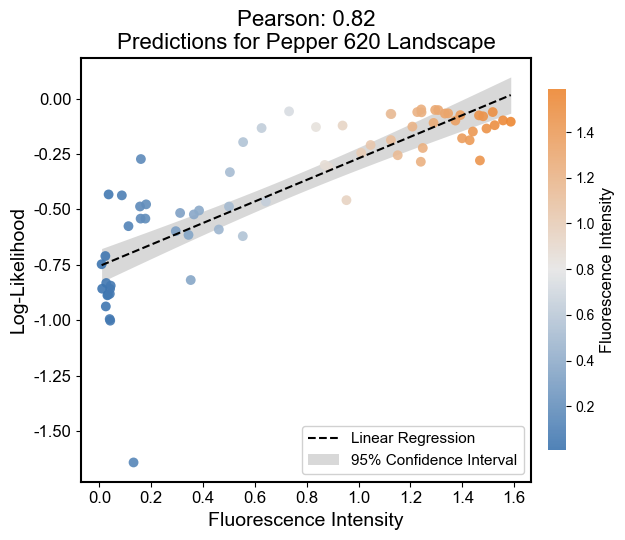

In [4]:
# Pepper 620
fig, ax = plt.subplots(figsize=(6.5, 5.5))
d = systems["620"]
sc = plot_pepper_correlation(ax, d["activity"], d["ll"], "Predictions for Pepper 620 Landscape")
cbar = fig.colorbar(sc, ax=ax, shrink=0.85, pad=0.03)
cbar.set_label("Fluorescence Intensity", fontsize=12)
cbar.ax.tick_params(labelsize=10)
cbar.outline.set_visible(False)
plt.tight_layout()
save_fig("aptamer_pepper_620_correlation")
plt.show()

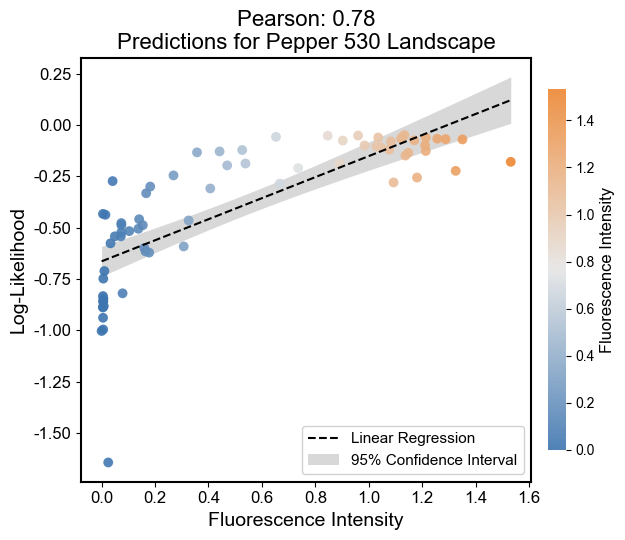

In [5]:
# Pepper 530
fig, ax = plt.subplots(figsize=(6.5, 5.5))
d = systems["530"]
sc = plot_pepper_correlation(ax, d["activity"], d["ll"], "Predictions for Pepper 530 Landscape")
cbar = fig.colorbar(sc, ax=ax, shrink=0.85, pad=0.03)
cbar.set_label("Fluorescence Intensity", fontsize=12)
cbar.ax.tick_params(labelsize=10)
cbar.outline.set_visible(False)
plt.tight_layout()
save_fig("aptamer_pepper_530_correlation")
plt.show()

## 2. DMS vs Generative Design

Violin plot comparing the number of mutations in sequences from Deep Mutational Scanning (DMS) vs Generative Design.

DMS: 30 sequences, Generative: 93 sequences


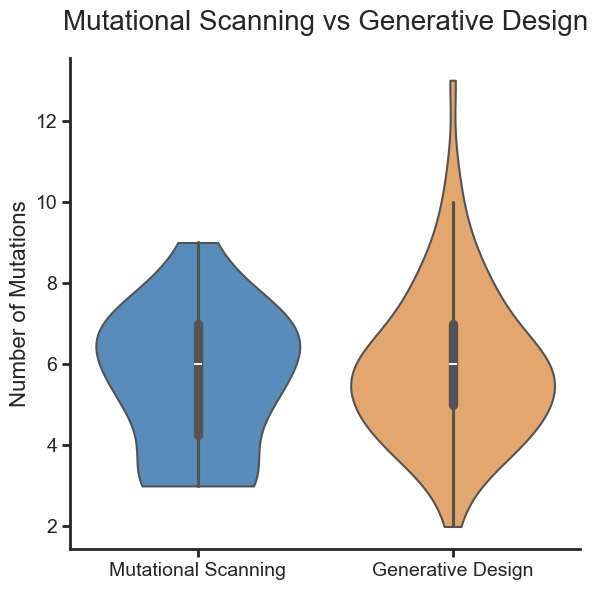

In [12]:
plt.rcParams["axes.linewidth"] = 2.0  # thicker axes for violin plots

# Load DMS and Generative data
df_dms = pd.read_csv(APTAMER_DATA_DIR / "pepper_active_sequences_mutations.tsv", sep='\t')
df_dms['Category'] = 'Mutational Scanning'

df_gen = pd.read_csv(APTAMER_DATA_DIR / "Pepper_aptamer_mutations_rate.tsv", sep='\t')
df_gen['Category'] = 'Generative Design'

df_compare = pd.concat([df_dms[['mutations', 'Category']], df_gen[['mutations', 'Category']]], ignore_index=True)
df_compare = df_compare[df_compare['mutations'] <= 16]

print(f"DMS: {len(df_dms)} sequences, Generative: {len(df_gen)} sequences")

plt.figure(figsize=(6, 6))
sns.set_style("ticks")
palette = {"Mutational Scanning": "#478ecc", "Generative Design": "#f5a65b"}
ax = sns.violinplot(data=df_compare, x="Category", y="mutations", palette=palette,
                    inner="box", linewidth=1.5, cut=0,
                    order=["Mutational Scanning", "Generative Design"])
plt.title("Mutational Scanning vs Generative Design", fontsize=20, pad=20)
plt.ylabel("Number of Mutations", fontsize=16)
plt.xlabel("")
ax.tick_params(axis='both', which='major', labelsize=14, width=2.0, length=6)
sns.despine()
plt.tight_layout()
save_fig("aptamer_dms_vs_generative")
plt.show()

## 3. Mutation Site Frequency Logo

Sequence logo showing base frequencies at mutated positions in generated Pepper RNA variants.

In [7]:
WILD_TYPE = 'UCCCCAAUCGUAGCGUGUCGACCUGCUUCGGCAGGCACUGGCGCUGGGA'
SEQ_LENGTH = len(WILD_TYPE)


def load_fasta(fasta_file):
    """Parse FASTA file."""
    sequences = []
    with open(fasta_file) as f:
        seq, header = '', ''
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                if seq:
                    sequences.append({'header': header, 'sequence': seq.upper().replace('T', 'U')})
                header, seq = line[1:], ''
            else:
                seq += line
        if seq:
            sequences.append({'header': header, 'sequence': seq.upper().replace('T', 'U')})
    return sequences


def calc_position_frequencies(sequences, wild_type):
    """Calculate base frequencies at each position."""
    seq_len = len(wild_type)
    mutated_positions = set()
    position_bases = {i: {'A': 0, 'U': 0, 'C': 0, 'G': 0} for i in range(seq_len)}

    for seq_data in sequences:
        seq = seq_data['sequence']
        if len(seq) != seq_len:
            continue
        for pos in range(seq_len):
            base = seq[pos]
            if base in position_bases[pos]:
                position_bases[pos][base] += 1
            if seq[pos] != wild_type[pos]:
                mutated_positions.add(pos)

    total = len([s for s in sequences if len(s['sequence']) == seq_len])
    freqs = {}
    for pos in range(seq_len):
        freqs[pos] = {b: c / total if total > 0 else 0 for b, c in position_bases[pos].items()}

    return freqs, sorted(mutated_positions)


def draw_logo_letter(ax, letter, x, y, width, height, color):
    """Draw a single letter in the logo."""
    fp = FontProperties(family='Arial', weight='normal')
    tp = TextPath((0, 0), letter, size=1, prop=fp)
    bbox = tp.get_extents()
    bw, bh = bbox.width, bbox.height
    if bw > 0 and bh > 0:
        sx, sy = width / bw, height / bh
        transform = transforms.Affine2D().scale(sx, sy).translate(
            x - width/2 + (width - bw*sx)/2, y)
        patch = PathPatch(tp, facecolor=color, edgecolor='none',
                         transform=transform + ax.transData)
        ax.add_patch(patch)


def plot_sequence_logo(freqs, positions, n_seqs, title, color='#3498DB', save_name=None):
    """Plot sequence logo for given positions."""
    if not positions:
        print("No mutated positions found")
        return

    fig_width = max(12, len(positions) * 0.6)
    fig, ax = plt.subplots(figsize=(fig_width, 4))
    bar_width = 0.8

    for i, pos in enumerate(positions):
        current_y = 0
        base_freqs = sorted(freqs[pos].items(), key=lambda x: x[1])
        for base, freq in base_freqs:
            if freq > 0.01:
                draw_logo_letter(ax, base, i, current_y, bar_width * 0.9, freq, color)
                current_y += freq

    ax.set_xlim(-0.5, len(positions) - 0.5)
    ax.set_ylim(0, 1.05)
    ax.set_xticks(range(len(positions)))
    ax.set_xticklabels([str(p + 1) for p in positions], fontsize=9)
    ax.set_ylabel('Probability', fontsize=12)
    ax.set_yticks([0, 0.5, 1.0])
    ax.set_title(title, fontsize=14, fontweight='normal', pad=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    if save_name:
        save_fig(save_name)
    plt.show()

Loaded 93 sequences
Mutated positions (1-based): [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 24, 25, 26, 27, 28, 29, 30, 32, 33, 34, 36, 39, 40, 41, 45, 48]


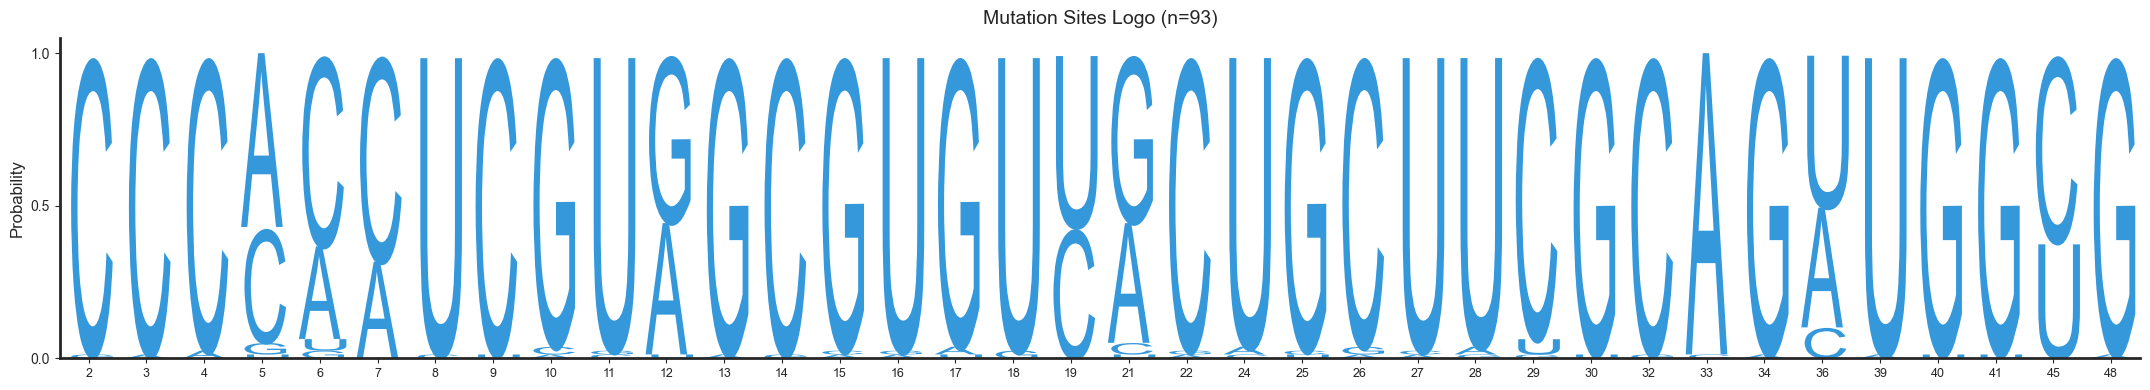

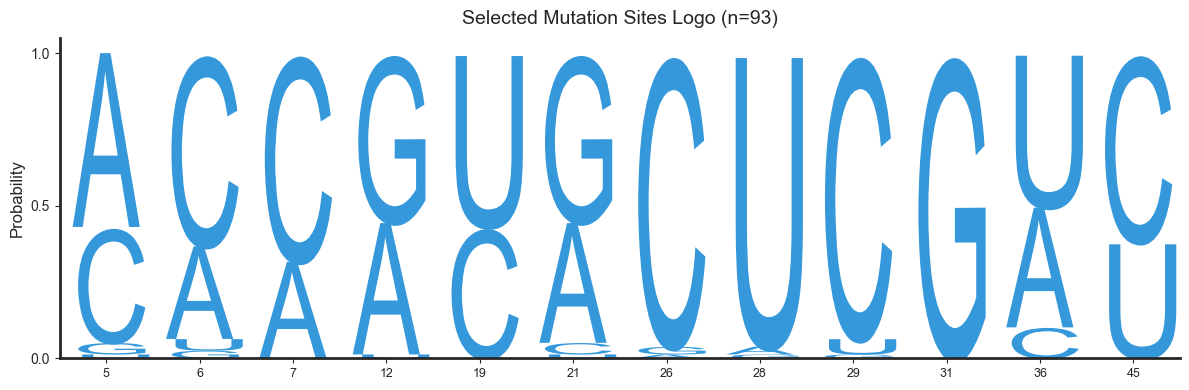

In [8]:
# Load generated sequences and compute mutation frequencies
sequences = load_fasta(APTAMER_DATA_DIR / "Pepper_aptamer_generated.fasta")
print(f"Loaded {len(sequences)} sequences")

freqs, mut_positions = calc_position_frequencies(sequences, WILD_TYPE)
print(f"Mutated positions (1-based): {[p+1 for p in mut_positions]}")

# Plot all mutated positions
plot_sequence_logo(freqs, mut_positions, len(sequences),
                   f'Mutation Sites Logo (n={len(sequences)})',
                   save_name="aptamer_mutation_logo_all")

# Plot selected key positions
SELECTED = [p - 1 for p in [5, 6, 7, 12, 19, 21, 26, 28, 29, 31, 36, 45]]
plot_sequence_logo(freqs, SELECTED, len(sequences),
                   f'Selected Mutation Sites Logo (n={len(sequences)})',
                   save_name="aptamer_mutation_logo_selected")

## 4. Performance-grouped Mutation Logo

Sequence logos grouped by experimental activity change:
- Improved/Neutral (change >= -5%): blue
- Decreased (change < -5%): coral

In [9]:
# Use pepper_prediction_data.json (620nm) for performance grouping
entries_620 = pepper_data["pepper_620"]

# First entry as reference (pepper_C5A_A21G_C36U)
wt_activity = entries_620[0]["fluorescence_intensity"]
print(f"Reference 620nm activity: {wt_activity:.4f} ({entries_620[0]['header']})")
print(f"Total sequences: {len(entries_620)}")

# Classify by performance
improved_seqs, decreased_seqs = [], []
for e in entries_620:
    activity = e["fluorescence_intensity"]
    sequence = e["sequence"].upper().replace('T', 'U')
    change_pct = (activity / wt_activity - 1) * 100
    seq_data = {'sequence': sequence, 'change_pct': change_pct}
    if change_pct >= -5:
        improved_seqs.append(seq_data)
    else:
        decreased_seqs.append(seq_data)

print(f"Improved/Neutral: {len(improved_seqs)}, Decreased: {len(decreased_seqs)}")

Reference 620nm activity: 1.1261 (pepper_C5A_A21G_C36U)
Total sequences: 70
Improved/Neutral: 28, Decreased: 42


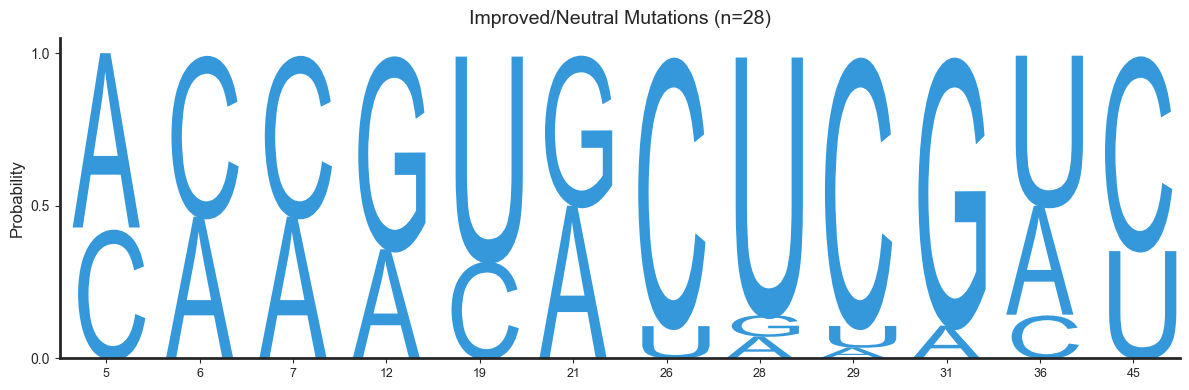

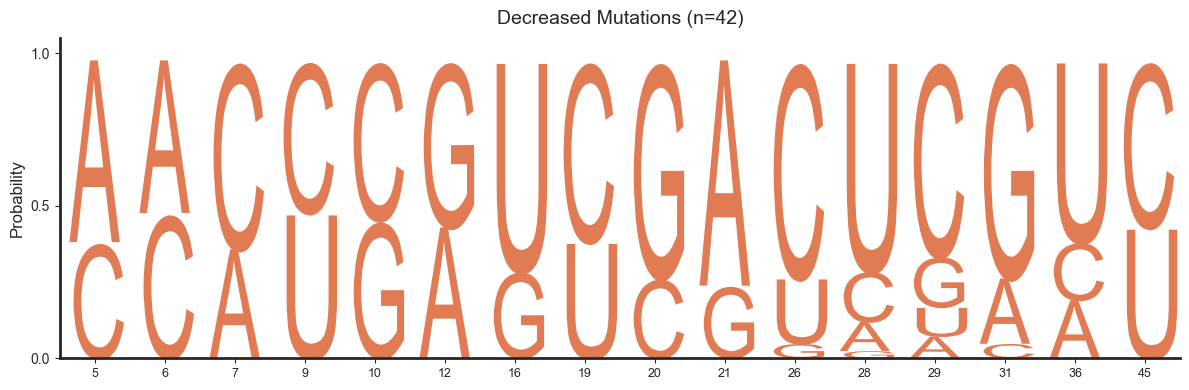

In [10]:
def calc_freq_from_seqdata(seq_list, wild_type):
    """Calculate position frequencies from sequence data list."""
    seq_len = len(wild_type)
    mutated_positions = set()
    position_bases = {i: {'A': 0, 'U': 0, 'C': 0, 'G': 0} for i in range(seq_len)}

    for sd in seq_list:
        seq = sd['sequence']
        if len(seq) != seq_len:
            continue
        for pos in range(seq_len):
            base = seq[pos]
            if base in position_bases[pos]:
                position_bases[pos][base] += 1
            if seq[pos] != wild_type[pos]:
                mutated_positions.add(pos)

    total = len(seq_list)
    freqs = {pos: {b: c/total if total > 0 else 0 for b, c in position_bases[pos].items()}
             for pos in range(seq_len)}
    return freqs, sorted(mutated_positions)


freq_imp, pos_imp = calc_freq_from_seqdata(improved_seqs, WILD_TYPE)
freq_dec, pos_dec = calc_freq_from_seqdata(decreased_seqs, WILD_TYPE)

# Individual logos
plot_sequence_logo(freq_imp, pos_imp, len(improved_seqs),
                   f'Improved/Neutral Mutations (n={len(improved_seqs)})', color='#3498DB',
                   save_name="aptamer_logo_improved")
plot_sequence_logo(freq_dec, pos_dec, len(decreased_seqs),
                   f'Decreased Mutations (n={len(decreased_seqs)})', color='#E07B54',
                   save_name="aptamer_logo_decreased")

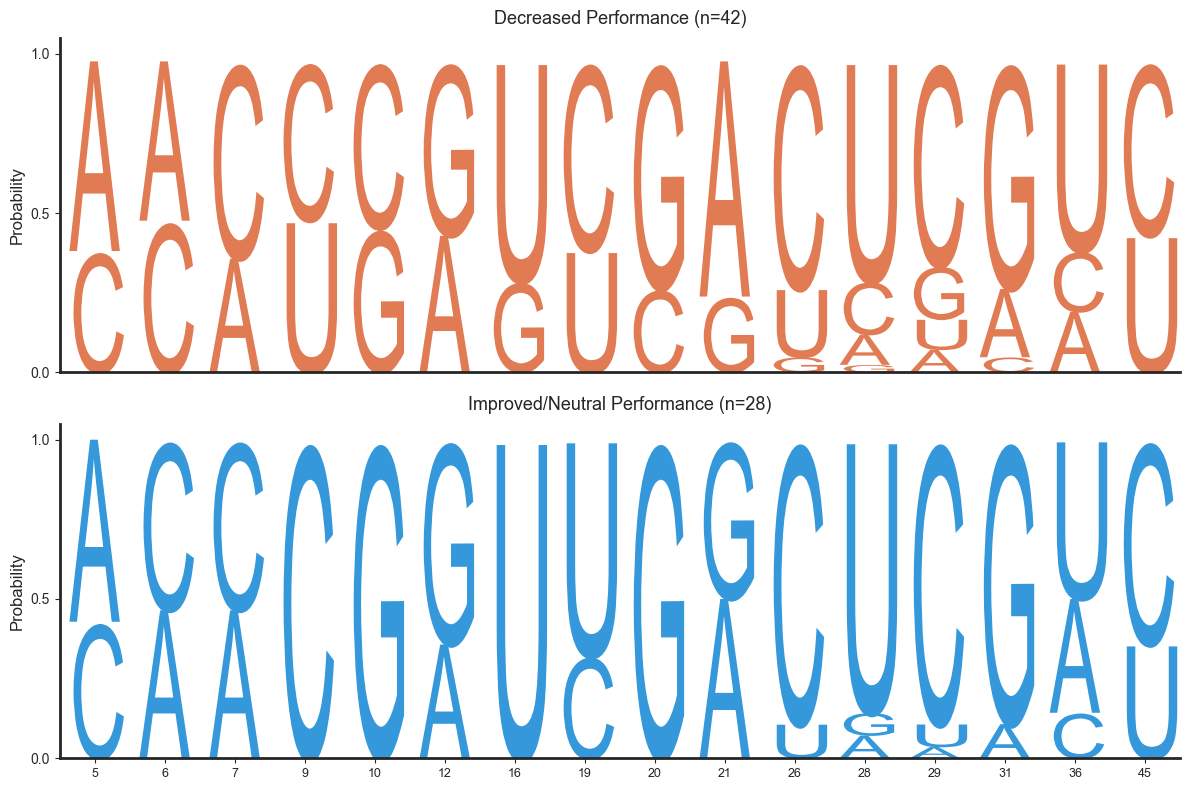

In [11]:
# Combined comparison plot
all_positions = sorted(set(pos_imp) | set(pos_dec))
fig_width = max(12, len(all_positions) * 0.7)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(fig_width, 8))
bar_width = 0.8

# Top: Decreased (coral)
for i, pos in enumerate(all_positions):
    current_y = 0
    if pos in freq_dec:
        for base, freq in sorted(freq_dec[pos].items(), key=lambda x: x[1]):
            if freq > 0.01:
                draw_logo_letter(ax1, base, i, current_y, bar_width * 0.9, freq, '#E07B54')
                current_y += freq

ax1.set_xlim(-0.5, len(all_positions) - 0.5)
ax1.set_ylim(0, 1.05)
ax1.set_ylabel('Probability', fontsize=12)
ax1.set_yticks([0, 0.5, 1.0])
ax1.set_xticks([])
ax1.set_title(f'Decreased Performance (n={len(decreased_seqs)})', fontsize=13, pad=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Bottom: Improved/Neutral (blue)
for i, pos in enumerate(all_positions):
    current_y = 0
    if pos in freq_imp:
        for base, freq in sorted(freq_imp[pos].items(), key=lambda x: x[1]):
            if freq > 0.01:
                draw_logo_letter(ax2, base, i, current_y, bar_width * 0.9, freq, '#3498DB')
                current_y += freq

ax2.set_xlim(-0.5, len(all_positions) - 0.5)
ax2.set_ylim(0, 1.05)
ax2.set_ylabel('Probability', fontsize=12)
ax2.set_yticks([0, 0.5, 1.0])
ax2.set_xticks(range(len(all_positions)))
ax2.set_xticklabels([str(p + 1) for p in all_positions], fontsize=9)
ax2.set_title(f'Improved/Neutral Performance (n={len(improved_seqs)})', fontsize=13, pad=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
save_fig("aptamer_logo_combined_comparison")
plt.show()